In [123]:
import sys
import subprocess   
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt
import seaborn as sns

In [124]:
PROJECT_ROOT = Path(r'C:\Users\user\Desktop\studia\Biologiasystemow2')
SCRIPTS_DIR  = PROJECT_ROOT / 'scripts'
DATA_PATH    = SCRIPTS_DIR / 'single-cell-tracks_exp1-6_noErbB2.csv.gz'
META_PATH    = SCRIPTS_DIR / '01-readme-experiment-description_2022-04-05.csv'
OUTPUT_DIR   = PROJECT_ROOT / 'outputs'

INPUT_SUMMARY = OUTPUT_DIR / 'comparison_mutation_ERKKTR_ratio' / 'block_level_summary.csv'


In [125]:
def run_data_generation():
    """
    Runs an external script that generates data used for
    signal spread analysis.
    """

    cmd = [
        sys.executable, str(SCRIPTS_DIR / "compare_spatiotemporal_behavior.py"),
        "--data-path", str(DATA_PATH),
        "--meta-path", str(META_PATH),
        "--group-by", "mutation",
        "--signal-col", "ERKKTR_ratio",
        "--spatial-radius", "60.0",
        "--future-window-frames", "3",
        "--output-dir", str(OUTPUT_DIR)
    ]

    process = subprocess.Popen(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1
    )

    for line in process.stdout:
        print(line, end="")

    process.wait()

In [134]:
def perform_mutation_comparison(block_summary_path: Path, output_dir: Path) -> pd.DataFrame:
    """
    Loads block-level results, calculates the mean Relative Risk (RR)
    and standard error (SE), and then compares mutants with WT
    using the Mann–Whitney test with Bonferroni correction.
    """

    df = pd.read_csv(block_summary_path)
    df = df.dropna(subset=['comparison_group', 'relative_risk'])

    wt_group = 'WT'
    wt_data = df[df['comparison_group'] == wt_group]['relative_risk'].values
    
    if len(wt_data) == 0:
        raise ValueError("No data available for the WT control group.")

    mutations = [m for m in df['comparison_group'].unique() if m != wt_group]
    n_comparisons = len(mutations)

    alpha = 0.05
    alpha_adj = alpha / n_comparisons

    results = []

    for mut in mutations:
        mut_data = df[df['comparison_group'] == mut]['relative_risk'].values

        mean_rr = np.mean(mut_data)
        se_rr = np.std(mut_data, ddof=1) / np.sqrt(len(mut_data)) if len(mut_data) > 1 else 0.0

        _, p_raw = mannwhitneyu(mut_data, wt_data, alternative='two-sided')
        

        results.append({
            'mutation': mut,
            'mean_RR': mean_rr,
            'std_error': se_rr,
            'p_value_vs_WT': p_raw,
            'significant': p_raw < alpha_adj
        })

    results_df = pd.DataFrame(results)
    results_df.to_csv(Path(output_dir) / 'mutations_comparison_table.csv', index=False)

    return results_df

In [127]:
results = perform_mutation_comparison(INPUT_SUMMARY, OUTPUT_DIR)
display(results)

,mutation,mean_RR,std_error,p_value_vs_WT,significant
0,AKT1_E17K,1.581421,0.071932,3.461467e-03,True
1,PIK3CA_E545K,1.707110,0.031885,1.835290e-01,False
2,PIK3CA_H1047R,3.200310,0.130643,3.063664e-09,True
3,PTEN_del,1.556633,0.021624,3.660584e-07,True


In [132]:
def plot_results(results_df: pd.DataFrame, save_path: Path):
    """
    Generates a comparison plot with mutants shown as bars and WT displayed as a horizontal baseline.
    """
    plt.figure(figsize=(10, 6))
    sns.set_theme(style="whitegrid")

    raw_df = pd.read_csv(INPUT_SUMMARY)
    wt_mean = raw_df[raw_df['comparison_group'] == 'WT']['relative_risk'].mean()

    mutants_df = results_df[results_df['mutation'] != 'WT'].copy()

    ax = sns.barplot(
        data=mutants_df,
        x='mutation',
        y='mean_RR',
        hue='mutation',
        palette='muted',
        edgecolor='black'
    )

    plt.axhline(y=wt_mean, color='red', linestyle='--', linewidth=2, label=f'WT Baseline ({wt_mean:.2f})')

    for i, (idx, row) in enumerate(mutants_df.iterrows()):
        ax.errorbar(
            i, 
            row['mean_RR'], 
            yerr=row['std_error'], 
            fmt='none', 
            c='black', 
            capsize=5
        )

        if row['significant']:
            ax.text(
                i, 
                row['mean_RR'] + row['std_error'] + 0.02, 
                '*', 
                ha='center', 
                va='bottom', 
                fontsize=20, 
                fontweight='bold',
                color='red'
            )

    plt.title('Spatiotemporal Signal Propagation: Mutants vs WT Baseline', fontsize=14, pad=20)
    plt.ylabel('Mean Relative Risk (RR) ± SE', fontsize=12)
    plt.xlabel('Mutation', fontsize=12)
    
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    max_y = max(mutants_df['mean_RR'].max() + mutants_df['std_error'].max(), wt_mean)
    plt.ylim(0, max_y + 0.5)
    
    plt.tight_layout()
    
    out_path = save_path / 'mutations_comparison_plot.png'
    plt.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"Saved plot to: {out_path}")

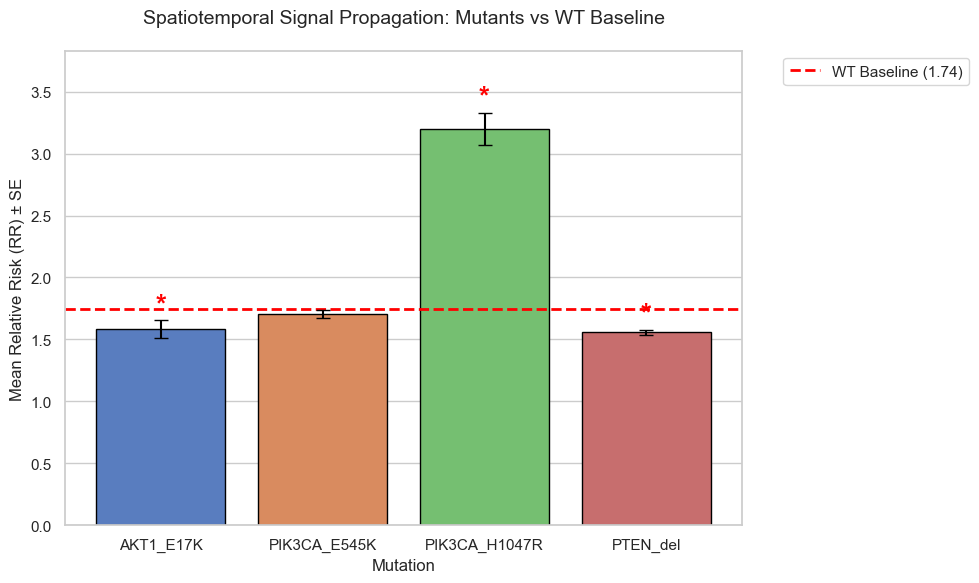

Saved plot to: C:\Users\user\Desktop\studia\Biologiasystemow2\outputs\comparison_mutation_ERKKTR_ratio\mutations_comparison_plot.png


In [133]:
final_results = perform_mutation_comparison(INPUT_SUMMARY, OUTPUT_DIR)
    
plot_results(final_results, INPUT_SUMMARY.parent)

### Interpretation of Spatiotemporal Signal Propagation

**Statistical Analysis: Comparison of Mutations to WT**
Using the Mann–Whitney U test with Bonferroni correction, we analyzed how PI3K-AKT pathway mutations affect the coordination of ERK signaling. While the Wild Type (**WT**) maintains a baseline Relative Risk (RR) of ~1.74, the mutants show distinct behaviors:

* **Enhanced Propagation:** The **PIK3CA_H1047R** mutation is the only one to significantly increase signal spread (RR ≈ 3.20, p < 0.001), nearly doubling the coordination potential compared to WT.
* **Reduced Propagation:** Interestingly, **AKT1_E17K** (RR = 1.58, p = 0.003) and **PTEN_del** (RR = 1.56, p < 0.001) significantly decrease the RR below WT levels, indicating a more fragmented and less collective signaling pattern.
* **No Significant Change:** The **PIK3CA_E545K** mutation (RR = 1.71, p = 0.184) behaves similarly to the WT, showing no statistically significant impact on ERK dynamics.

**Proposed Biological Mechanism:**
The divergent effects likely depend on the mutation's position within the signaling hierarchy. **PIK3CA_H1047R** acts at the plasma membrane, potentially promoting the secretion of paracrine factors (like EGFR ligands) or increasing sensitivity to neighbor-derived signals. This "hypersensitivity" facilitates the efficient spread of ERK activity waves across the population.

In contrast, downstream mutations (**AKT1_E17K** and **PTEN_del**) generate high constitutive baseline activity. This creates "internal noise" and triggers negative feedback loops that desensitize the cells to external cues. Consequently, while these cells are highly active, they become "deaf" to their neighbors and signal asynchronously, leading to the observed drop in Relative Risk.